# A year in one market

This is the shortest useful thing pretium does: run a market for a
trading year, watch one company, and see what happened to it and why.

Everything here is deterministic. The same seed gives the same year,
on any machine, forever. Nothing is downloaded and nothing is random
in the sense of being unrepeatable.

You need `pip install pretium matplotlib`. It takes about twenty
seconds to run.

## The market

A universe is a roster of companies. Here one is built by hand with
Apple's rough shape (price, share count, earnings, book value) and
thirty-nine others are generated, so the market has something to
co-move with. The numbers are a starting state, not a forecast: this
is a company like Apple in a market like the US one, not Apple.

In [1]:
import pretium as pt

aapl = pt.Instrument(
    "AAPL", "technology",
    initial_price=75.0,          # roughly where it started 2020
    shares_outstanding=17.77e9,
    eps=2.97,
    book_value_per_share=5.09,
    avg_volume=140e6,
    beta=1.2,
)

universe = pt.Universe([aapl])
universe.extend(pt.Universe.random(39, seed=7))

print(f"{len(universe)} companies, fingerprint {universe.fingerprint}")
print(f"model preset: {pt.ModelParams.from_preset().fingerprint}")

40 companies, fingerprint 26723eeb70136708af95ea1c55b98145f1c38774df4bcc4fb8aac29907592bb5
model preset: pt-v10


The fingerprints matter more than they look. A universe fingerprint and
a preset name and a seed are a complete description of a market: quote
those three and anyone can reproduce your run exactly.

## Two runs of the same year

Both runs use the same seed, the same companies and the same calm
baseline: the VIX pinned at 15 and corporate borrowing at 5.5%. The
second run adds two crises and nothing else, so every difference
between the two lines below is caused by them.

Day 60 is a fear shock: the VIX jumps to 45 and decays back over three
weeks, roughly a bad correction. Day 150 is worse: the VIX to 65 over a
month with corporate borrowing costs up four points at the same time,
which is fear plus a credit squeeze.

A scenario pins macro state. It does not tell prices what to do: the
crisis is an input, the market's reaction to it is not.

In [2]:
CALM = {"vix": 15.0, "corporate_bond_yield": 0.055}
CRISES = [
    ("correction", 60, 21, 45.0, None),
    ("credit crunch", 150, 30, 65.0, 0.095),
]

quiet_scenario = pt.Scenario().hold(**CALM)

crisis_scenario = pt.Scenario().hold(**CALM)
for _name, begin, over, vix_peak, yield_peak in CRISES:
    crisis_scenario = crisis_scenario.ramp(
        "vix", start=vix_peak, end=CALM["vix"], over=over, begin=begin)
    if yield_peak is not None:
        crisis_scenario = crisis_scenario.ramp(
            "corporate_bond_yield", start=yield_peak,
            end=CALM["corporate_bond_yield"], over=over, begin=begin)

print(f"day 59: {crisis_scenario.at(59)}")
print(f"day 60: {crisis_scenario.at(60)}")
print(f"day 150: {crisis_scenario.at(150)}")

day 59: {'vix': 15.0, 'corporate_bond_yield': 0.055}
day 60: {'vix': 45.0, 'corporate_bond_yield': 0.055}
day 150: {'vix': 65.0, 'corporate_bond_yield': 0.095}


In [3]:
import pyarrow as pa, pyarrow.compute as pc

def run_year(scenario, days=252):
    engine = pt.Engine(seed=2024, universe=universe)
    for day in range(days):
        scenario.apply(engine, day)
        engine.run_days(1, first_day=day, record=True)
    return engine

def daily_close(engine, ticker="AAPL"):
    """One name's closing price per day."""
    bars = pa.table(engine.bars(grain="day"))
    idx = engine.tickers.index(ticker)
    rows = pc.filter(bars, pc.equal(bars["instrument_id"], idx))
    return rows["close"].to_pylist()

QUIET = run_year(quiet_scenario)
SHOCKED = run_year(crisis_scenario)
quiet_path = daily_close(QUIET)
shocked_path = daily_close(SHOCKED)

print(f"quiet:   {quiet_path[0]:.2f} -> {quiet_path[-1]:.2f}")
print(f"crises:  {shocked_path[0]:.2f} -> {shocked_path[-1]:.2f}")

quiet:   74.84 -> 94.74
crises:  74.84 -> 94.50


## The picture

The shaded bands are the crises. The two lines are the same company,
the same seed and the same starting state; the only difference is that
one market was frightened twice.

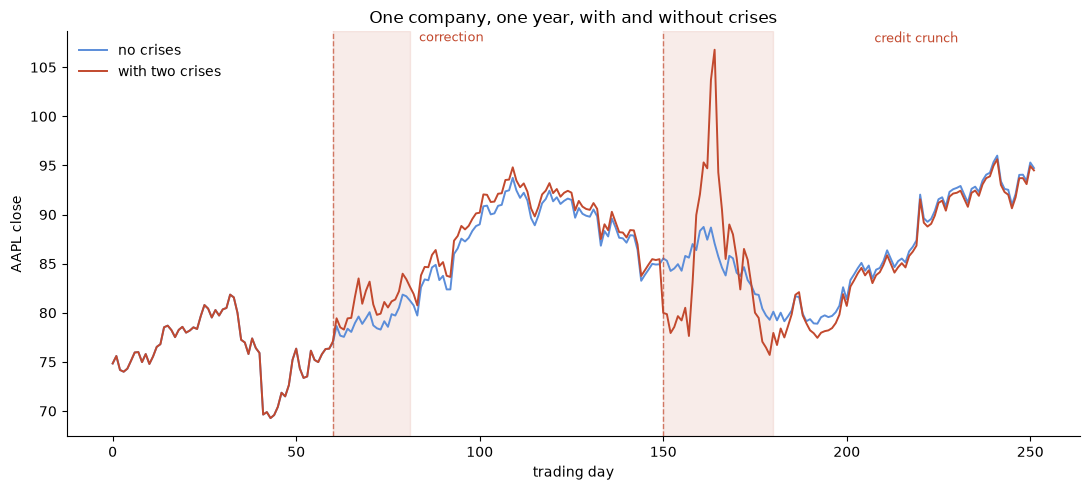

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(quiet_path, linewidth=1.4, label="no crises", color="#5b8dd9")
ax.plot(shocked_path, linewidth=1.4, label="with two crises", color="#c2492e")

for name, start, length, _vix, _yield in CRISES:
    ax.axvspan(start, start + length, color="#c2492e", alpha=0.10)
    ax.axvline(start, color="#c2492e", linewidth=1.0, linestyle="--", alpha=0.7)
    ax.annotate(name, xy=(start, ax.get_ylim()[1]), xytext=(start + 2, 0),
                textcoords="offset points", fontsize=9, color="#c2492e",
                va="top")

ax.set_xlabel("trading day")
ax.set_ylabel("AAPL close")
ax.set_title("One company, one year, with and without crises")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## What the crises did

Two numbers are worth reading off. The drawdown is how far the price
fell from its own high, which is the loss a holder actually lives
through. Realised volatility is how violent the ride was.

In [5]:
import statistics as st

def drawdown(path):
    peak, worst = path[0], 0.0
    for price in path:
        peak = max(peak, price)
        worst = min(worst, price / peak - 1)
    return worst

def annual_vol(path):
    rets = [path[i] / path[i - 1] - 1 for i in range(1, len(path))]
    return st.pstdev(rets) * 252 ** 0.5

print(f"{'':16s} {'quiet':>10s} {'with crises':>12s}")
print(f"{'return':16s} {quiet_path[-1] / quiet_path[0] - 1:>10.1%} "
      f"{shocked_path[-1] / shocked_path[0] - 1:>12.1%}")
print(f"{'max drawdown':16s} {drawdown(quiet_path):>10.1%} "
      f"{drawdown(shocked_path):>12.1%}")
print(f"{'volatility':16s} {annual_vol(quiet_path):>10.1%} "
      f"{annual_vol(shocked_path):>12.1%}")

                      quiet  with crises
return                26.6%        26.3%
max drawdown         -15.8%       -29.1%
volatility            21.9%        32.9%


## Why the price moved

A real market never tells you why. This one does, because it computed
the reasons: every price move is a sum of named components, and they
add up to the change exactly.

Below is AAPL over the credit crunch, days 150 to 180, with each
component's total contribution. The units are the model's internal
mispricing scale rather than currency; the ranking and the signs are
what to read.

In [6]:
truth = pa.table(SHOCKED.truth())
idx = SHOCKED.tickers.index("AAPL")
window = pc.and_(
    pc.equal(truth["instrument_id"], idx),
    pc.and_(pc.greater_equal(truth["day"], 150),
            pc.less(truth["day"], 180)),
)
rows = pc.filter(truth, window)

# From the SECOND row on: the first row's components caused the move
# into the window's opening price, not a move inside it.
inside = rows.slice(1)
totals = {name: pc.sum(inside[name]).as_py() for name in pt.Engine.FACTORS}
for name, value in sorted(totals.items(), key=lambda kv: -abs(kv[1])):
    print(f"  {name:22s} {value:>+12.5f}")
print(f"  {'sum':22s} {sum(totals.values()):>+12.5f}")

s_series = rows["mispricing_s"].to_pylist()
print(f"  {'change in mispricing':22s} {s_series[-1] - s_series[0]:>+12.5f}")

  random_noise               -0.08226
  short_squeeze_effect       -0.03600
  jump                       -0.03262
  reversion                  +0.01962
  crowd_lean                 +0.00876
  momentum                   -0.00133
  company_news               +0.00000
  order_flow_impact          +0.00000
  sum                        -0.12383
  change in mispricing       -0.12383


The last two numbers match, which is the point: the components are not
an interpretation of the move, they are the move. `reversion` pulling
against the others is the market's own pressure back toward fair
value.

`03-why-did-the-price-move.ipynb` does this properly, tick by tick.

## What to read next

- `01-first-simulation.ipynb` goes under the hood: the order book,
  determinism, and how a run is made citable.
- `04-how-realistic-is-this.ipynb` is the honest part: which statistics
  this market matches, which it does not, and what that forbids.
- `09-a-pandemic-shaped-market.ipynb` drives a real 2020-21 macro path
  through the model and scores the result against what Apple did.

One thing to carry forward: this market is calibrated to behave like a
market, not to predict one. It is for testing whether a strategy or an
agent survives conditions you choose, on a tape nobody has seen.